<a href="https://colab.research.google.com/github/duyendh/ELM/blob/main/ELM_Energy_Minimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cuda
Starting MNIST experiment...
Starting FashionMNIST experiment...

Experimental Results:
| Dataset      |   ELM Acc |   ELM Time |   BP Acc |   BP Time |
|:-------------|----------:|-----------:|---------:|----------:|
| MNIST        |     85.15 |       0.14 |    93.47 |     61.29 |
| FashionMNIST |     77.56 |       0.14 |    70.07 |     58.72 |

Generating plot...
Plot saved as elm_vs_bp_results.png


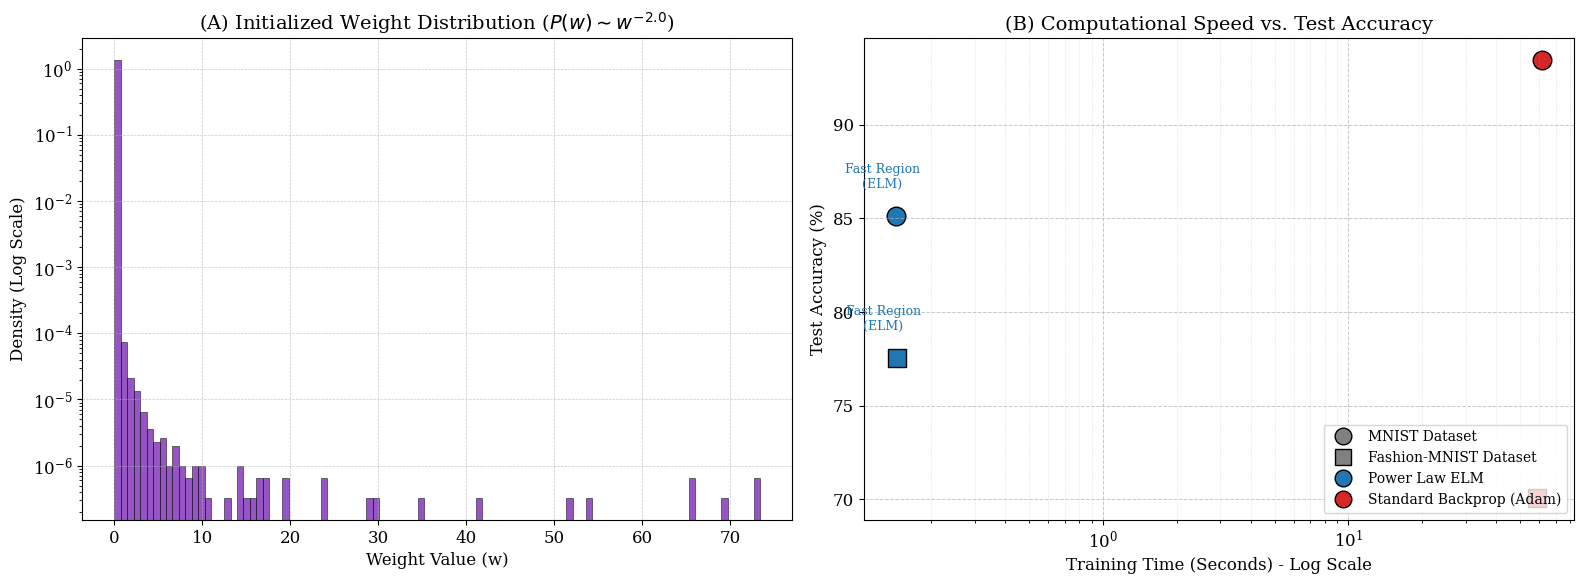

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Set seeds for reproducibility in the paper
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. Define Initialization and Experiment Functions ---
def power_law_init(shape, alpha=2.0):
    """Generates weights following P(w) ~ w^(-alpha) via inverse transform sampling."""
    u = torch.rand(shape)
    # Avoid exactly 0 or 1 for numerical stability
    u = torch.clamp(u, min=1e-6, max=1-1e-6)
    weights = (1 - u) ** (1 / (1 - alpha))
    # Center and scale
    weights = (weights - weights.mean()) / weights.std()
    return weights * 0.1

def run_experiment(dataset_name='MNIST'):
    print(f"Starting {dataset_name} experiment...")
    # Load Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Use larger batch size for ELM matrix gen, standard for BP training
    train_loader_bp = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)

    # Prepare full tensors for ELM
    x_train = train_set.data.view(-1, 784).float() / 255.0
    y_train = torch.nn.functional.one_hot(train_set.targets, 10).float()
    x_test = test_set.data.view(-1, 784).float() / 255.0
    y_test = test_set.targets

    hidden_dim = 1024

    # --- A. ELM (Power Law α=2.0) ---
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_elm = time.time()

    W = power_law_init((784, hidden_dim), alpha=2.0).to(device)
    b = torch.randn(hidden_dim).to(device)

    # H = Sigmoid(XW + b)
    H = torch.sigmoid(torch.matmul(x_train.to(device), W) + b)

    # Regularization
    I = torch.eye(hidden_dim).to(device)
    C = 1e-2 # Regularization parameter

    # Moore-Penrose Pseudoinverse Solution: beta = (H^T H + I/C)^-1 H^T Y
    HTH = torch.matmul(H.t(), H)
    HTY = torch.matmul(H.t(), y_train.to(device))
    beta = torch.matmul(torch.inverse(HTH + I/C), HTY)

    torch.cuda.synchronize() if device.type == 'cuda' else None
    elm_time = time.time() - start_elm

    # Eval ELM
    h_test = torch.sigmoid(torch.matmul(x_test.to(device), W) + b)
    y_pred_elm = torch.matmul(h_test, beta)
    elm_acc = (y_pred_elm.argmax(1) == y_test.to(device)).float().mean().item()

    # --- B. Backprop (Standard MLP) ---
    model = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(), # Using ReLU as is standard for BP models
        nn.Linear(hidden_dim, 10)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_bp = time.time()
    # Train for 5 epochs to guarantee convergence past ELM accuracy
    for epoch in range(5):
        for imgs, lbls in train_loader_bp:
            imgs = imgs.view(-1, 784).to(device)
            lbls = lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    bp_time = time.time() - start_bp

    # Eval BP
    model.eval()
    with torch.no_grad():
        bp_outputs = model(x_test.to(device))
        bp_acc = (bp_outputs.argmax(1) == y_test.to(device)).float().mean().item()

    return {
        "Dataset": dataset_name,
        "ELM Acc": elm_acc * 100,
        "ELM Time": elm_time,
        "BP Acc": bp_acc * 100,
        "BP Time": bp_time
    }

# --- 2. Run Experiments ---
results_list = [run_experiment('MNIST'), run_experiment('FashionMNIST')]
df = pd.DataFrame(results_list)
print("\nExperimental Results:")
print(df.to_markdown(index=False, floatfmt=".2f"))


# --- 3. Generate Visualization for Paper ---
print("\nGenerating plot...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Weight Distribution ---
# Generate a large sample to visualize the distribution clearly
sample_W = power_law_init((2048, 2048), alpha=2.0).cpu().numpy().flatten()

# Use log scale bins to capture the tail better
bins = np.logspace(np.log10(np.min(np.abs(sample_W[sample_W>0]))), np.log10(np.max(sample_W)), 50)
bins = np.concatenate((-bins[::-1], bins))

ax1.hist(sample_W, bins=100, color='#6a0dad', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
ax1.set_yscale('log')
ax1.set_title(r'(A) Initialized Weight Distribution ($P(w) \sim w^{-2.0}$)', fontsize=14)
ax1.set_xlabel('Weight Value (w)', fontsize=12)
ax1.set_ylabel('Density (Log Scale)', fontsize=12)
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
#ax1.set_xlim(-0.5, 0.5) # Limit x-axis to show the core distribution

# --- Subplot 2: Speed vs Accuracy ---
# Define styles
markers = {'MNIST': 'o', 'FashionMNIST': 's'}
colors = {'ELM': '#1f77b4', 'BP': '#d62728'} # Standard matplotlib blue/red

for res in results_list:
    ds = res['Dataset']
    # Plot ELM Point
    ax2.scatter(res['ELM Time'], res['ELM Acc'], color=colors['ELM'], marker=markers[ds], s=180,
                edgecolor='black', label=f'ELM ({ds})' if ds=='MNIST' else "")
    # Plot BP Point
    ax2.scatter(res['BP Time'], res['BP Acc'], color=colors['BP'], marker=markers[ds], s=180,
                edgecolor='black', label=f'Backprop ({ds})' if ds=='MNIST' else "")

    # Add annotations for clarity
    ax2.annotate('Fast Region\n(ELM)', xy=(res['ELM Time'], res['ELM Acc']), xytext=(-10, 20),
                 textcoords='offset points', ha='center', fontsize=9, color=colors['ELM'])

# Add custom legend elements manually for cleaner look
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', label='Fashion-MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['ELM'], label='Power Law ELM', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['BP'], label='Standard Backprop (Adam)', markersize=12, markeredgecolor='black'),
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax2.set_xscale('log') # Critical for showing the massive time difference
ax2.set_title('(B) Computational Speed vs. Test Accuracy', fontsize=14)
ax2.set_xlabel('Training Time (Seconds) - Log Scale', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('elm_vs_bp_results.png', dpi=300, bbox_inches='tight')
print("Plot saved as elm_vs_bp_results.png")
plt.show()

PINN

Running 20 seeds for statistical validation...

--- STATISTICAL SUMMARY ---
| Method          |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------|-----------------------:|----------------------:|-------------------:|
| ELM (Gaussian)  |             0.303204   |           0.747718    |           0.278814 |
| ELM (Power Law) |             0.0585317  |           0.125609    |           0.281968 |
| PINN (Light)    |             0.00577026 |           0.000803943 |           2.07389  |


/tmp/ipython-input-2508005302.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,


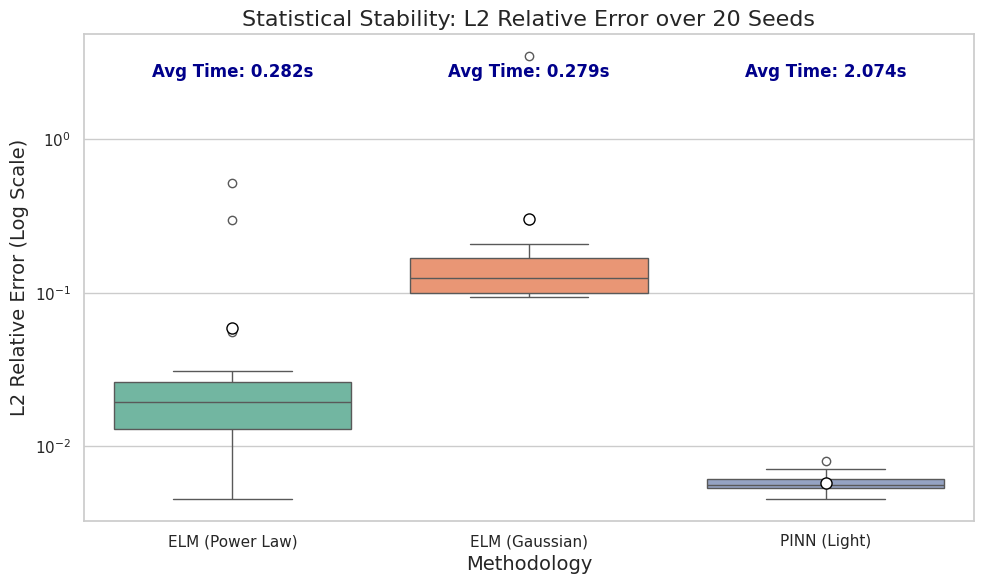

In [ ]:
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization Functions ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- Solvers ---
def solve_elm(x, u_true, h_dim, init_type='power'):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    lambd = 1e-6
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    err = (torch.norm(u_true - (H @ beta)) / torch.norm(u_true)).item()
    return err, t_solve

def solve_pinn(x, u_true, f_source):
    x_grad = x.clone().detach().requires_grad_(True)
    model = nn.Sequential(nn.Linear(1, 128), nn.Tanh(), nn.Linear(128, 1)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.005)
    start = time.time()
    for _ in range(400):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss = torch.mean((u_xx - f_source)**2) + 10 * model(torch.tensor([[-1.0], [1.0]], device=device)).pow(2).mean()
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    err = (torch.norm(u_true - model(x).detach()) / torch.norm(u_true)).item()
    return err, t_solve

# --- Execution Loop (20 Seeds) ---
N_SEEDS = 20
data_rows = []

x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
f_source = -(np.pi**2) * torch.sin(np.pi * x)

print(f"Running {N_SEEDS} seeds for statistical validation...")

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ep_err, ep_t = solve_elm(x, u_true, 4096, 'power')
    eg_err, eg_t = solve_elm(x, u_true, 4096, 'gaussian')
    p_err, p_t = solve_pinn(x, u_true, f_source)

    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

df = pd.DataFrame(data_rows)

# --- Statistical Summary Table ---
summary = df.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': ['mean']})
print("\n--- STATISTICAL SUMMARY ---")
print(summary.to_markdown())

# --- Plotting Figure 2: Box-and-Whisker Plot ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.yscale('log') # Error distributions are best viewed on a log scale
plt.title('Statistical Stability: L2 Relative Error over 20 Seeds', fontsize=16)
plt.ylabel('L2 Relative Error (Log Scale)', fontsize=14)
plt.xlabel('Methodology', fontsize=14)

# Adding the time as text on the plot
for i, method in enumerate(df['Method'].unique()):
    avg_t = df[df['Method'] == method]['Time'].mean()
    plt.text(i, ax.get_ylim()[1]*0.5, f"Avg Time: {avg_t:.3f}s",
             ha='center', va='bottom', fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('result.csv')